# Entrenamiento — Ms. Pac-Man DDQN

Este notebook es el registro del entrenamiento tal como corrió en Google Colab
(GPU T4, capa gratuita). Las salidas se conservan a propósito: son la evidencia
de los resultados que reporta el README.

**Dos correcciones sobre las salidas guardadas:**

1. El encabezado de la última celda decía *"RESULTADOS FINALES (1M PASOS)"*. El
   entrenamiento fue de **500 mil** pasos, no de un millón. Corregido en el código;
   la salida guardada abajo todavía muestra el texto viejo.
2. El puntaje de 914 se midió con un pipeline de evaluación que tenía un defecto de
   frameskip. Con el entorno correcto, el mismo modelo promedia **1 755**. Ver
   [`docs/frameskip.md`](../docs/frameskip.md).


In [ ]:
# ==============================================================================
# CELDA 1: INSTALACIÓN DE LIBRERÍAS Y DEPENDENCIAS
# ==============================================================================

# Instalamos la librería ale-py, que es la interfaz del Arcade Learning Environment
!pip install ale-py

# Instalamos gymnasium con los extras de 'atari' para tener acceso a los juegos
# También incluimos 'accept-rom-license' para aceptar la licencia de las ROMs de Atari
!pip install gymnasium[atari,accept-rom-license]

# Instalamos opencv-python para procesar las imágenes (escala de grises y redimensionamiento)
!pip install opencv-python

# Instalamos stable-baselines3, una librería de algoritmos de RL del estado del arte
# Incluimos '[extra]' para obtener los wrappers específicos de entornos Atari
!pip install stable-baselines3[extra]

In [ ]:
# ==============================================================================
# CELDA 2: IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================

# Importamos gymnasium, la librería principal para crear y manejar el entorno
import gymnasium as gym

# Importamos matplotlib.pyplot para poder visualizar gráficas y fotogramas del juego
import matplotlib.pyplot as plt

# Importamos numpy para el manejo eficiente de arreglos y operaciones matemáticas
import numpy as np

# Importamos cv2 (OpenCV) para aplicar las transformaciones visuales requeridas
import cv2

# Importamos deque de la librería collections para crear un buffer circular (stack)
from collections import deque

# Importamos random para permitir que nuestro agente tome decisiones aleatorias al inicio
import random

# Imprimimos un mensaje de confirmación para saber que todo se importó correctamente
print("Todas las librerías han sido importadas correctamente.")

Todas las librerías han sido importadas correctamente.


In [ ]:
 # ==============================================================================
# CELDA 3: EXPLORACIÓN DEL ESPACIO DE ESTADOS Y ACCIONES
# ==============================================================================

# Definimos una función para explorar las características básicas del entorno Ms. Pac-Man
def explorar_entorno():

    # Imprimimos un encabezado decorativo en la consola
    print("=" * 60)
    # Imprimimos el título de la sección
    print("   EXPLORACIÓN DEL ENTORNO MS. PAC-MAN (ALE)")
    # Imprimimos la línea inferior del encabezado decorativo
    print("=" * 60)

    # Importar ale_py.roms para registrar los entornos de Atari con Gymnasium
    import ale_py.roms

    # Creamos el entorno de Ms. Pac-Man v5 especificando que queremos renderizar en RGB
    env = gym.make("ALE/MsPacman-v5", render_mode="rgb_array")

    # Imprimimos un subtítulo para el espacio de observación
    print("\n--- Espacio de Observación ---")
    # Imprimimos el tipo de espacio de observación (debería ser Box)
    print(f"Tipo    : {env.observation_space}")
    # Imprimimos la forma del tensor de la imagen (210, 160, 3)
    print(f"Shape   : {env.observation_space.shape}")
    # Imprimimos el tipo de dato de los píxeles (uint8)
    print(f"Dtype   : {env.observation_space.dtype}")
    # Calculamos e imprimimos el total de píxeles multiplicando las dimensiones
    print(f"Pixeles : {210 * 160 * 3:,} valores por frame")

    # Imprimimos un subtítulo para el espacio de acción
    print("\n--- Espacio de Acción ---")
    # Imprimimos el tipo de espacio de acción (Discrete)
    print(f"Tipo         : {env.action_space}")
    # Imprimimos la cantidad total de acciones posibles (9 en Ms. Pac-Man)
    print(f"Cardinalidad : {env.action_space.n}")

    # Creamos un diccionario mapeando el ID numérico de la acción a su significado textual
    acciones = {0:"NOOP", 1:"UP", 2:"RIGHT", 3:"LEFT",
                4:"DOWN", 5:"DOWNRIGHT", 6:"DOWNLEFT",
                7:"UPRIGHT", 8:"UPLEFT"}

    # Imprimimos un subtítulo para el mapeo de acciones
    print("\nMapeo de acciones:")
    # Iteramos sobre los elementos del diccionario de acciones
    for idx, nombre in acciones.items():
        # Imprimimos el ID numérico y el nombre de la acción correspondiente
        print(f"  Acción {idx}: {nombre}")

    # Devolvemos el entorno creado para usarlo posteriormente
    return env

# Ejecutamos la función y guardamos el entorno en la variable 'env_exploracion'
env_exploracion = explorar_entorno()

   EXPLORACIÓN DEL ENTORNO MS. PAC-MAN (ALE)

--- Espacio de Observación ---
Tipo    : Box(0, 255, (210, 160, 3), uint8)
Shape   : (210, 160, 3)
Dtype   : uint8
Pixeles : 100,800 valores por frame

--- Espacio de Acción ---
Tipo         : Discrete(9)
Cardinalidad : 9

Mapeo de acciones:
  Acción 0: NOOP
  Acción 1: UP
  Acción 2: RIGHT
  Acción 3: LEFT
  Acción 4: DOWN
  Acción 5: DOWNRIGHT
  Acción 6: DOWNLEFT
  Acción 7: UPRIGHT
  Acción 8: UPLEFT


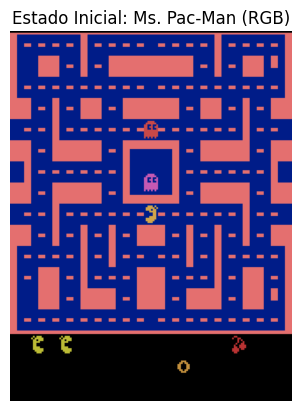

In [ ]:
# ==============================================================================
# CELDA 4: VISUALIZACIÓN DEL ESTADO INICIAL (RGB)
# ==============================================================================

# Reiniciamos el entorno para asegurar que Ms. Pac-Man está en la posición inicial
# Guardamos la observación y la información adicional, fijando una semilla (seed=42)
observacion, info = env_exploracion.reset(seed=42)

# Capturamos el fotograma actual del entorno como una matriz de píxeles RGB
frame = env_exploracion.render()

# Le indicamos a matplotlib que prepare la imagen 'frame' para mostrarla
plt.imshow(frame)

# Desactivamos los ejes (x e y) para que solo se vea la imagen del juego sin números
plt.axis('off')

# Añadimos un título a la gráfica
plt.title("Estado Inicial: Ms. Pac-Man (RGB)")

# Ejecutamos el comando para renderizar y mostrar la imagen en el notebook
plt.show()

# Cerramos este entorno exploratorio para liberar memoria
env_exploracion.close()

In [ ]:
# ==============================================================================
# CELDA 5: PREPROCESAMIENTO (GRAYSCALE, RESIZE) Y FRAME STACKING
# ==============================================================================

# Definimos la función que convertirá cada fotograma crudo al formato requerido por la red neuronal
def preprocesar_frame(frame: np.ndarray) -> np.ndarray:

    # Convertimos la imagen RGB a escala de grises usando OpenCV (reduce 3 canales a 1)
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

    # Redimensionamos la imagen de 210x160 a 84x84 píxeles usando interpolación de área
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)

    # Convertimos los valores enteros (0-255) a flotantes y dividimos entre 255.0 para normalizar a [0,1]
    normalized = resized.astype(np.float32) / 255.0

    # Devolvemos la imagen procesada
    return normalized

# Definimos una clase para gestionar el apilamiento de los fotogramas (Frame Stacking)
class FrameStacker:

    # Método constructor de la clase, recibe el número de fotogramas a apilar (por defecto 4)
    def __init__(self, n_frames: int = 4):
        # Guardamos el número de fotogramas como atributo de la instancia
        self.n_frames = n_frames
        # Creamos una cola doble (deque) que automáticamente elimina el elemento más viejo si se llena
        self.frames = deque(maxlen=n_frames)

    # Método para inicializar el stack al inicio de un episodio
    def reset(self, frame: np.ndarray) -> np.ndarray:
        # Procesamos el primer fotograma usando la función que definimos arriba
        proc = preprocesar_frame(frame)
        # Llenamos todo el stack repitiendo este primer fotograma 'n_frames' veces
        for _ in range(self.n_frames):
            # Añadimos el fotograma procesado a la cola
            self.frames.append(proc)
        # Combinamos los fotogramas de la cola en un solo tensor apilándolos en el último eje (canales)
        return np.stack(self.frames, axis=-1)

    # Método para actualizar el stack en cada paso de tiempo del juego
    def step(self, frame: np.ndarray) -> np.ndarray:
        # Procesamos el nuevo fotograma recibido
        proc = preprocesar_frame(frame)
        # Lo añadimos a la cola (esto empuja y elimina automáticamente el fotograma más antiguo)
        self.frames.append(proc)
        # Combinamos la cola actualizada en un tensor y lo devolvemos
        return np.stack(self.frames, axis=-1)

# Imprimimos un mensaje indicando que las herramientas de preprocesamiento están listas
print("Funciones de preprocesamiento y FrameStacker definidas correctamente.")

Funciones de preprocesamiento y FrameStacker definidas correctamente.


In [ ]:
# ==============================================================================
# CELDA 6: SIMULACIÓN DE LÍNEA BASE (POLÍTICA ALEATORIA)
# ==============================================================================

# Definimos una función para simular un episodio con acciones aleatorias
def evaluar_agente_aleatorio(num_episodios=5):

    # Creamos un entorno nuevo sin renderizado visual para que la simulación sea muy rápida
    env_eval = gym.make("ALE/MsPacman-v5")

    # Creamos una lista vacía para almacenar los puntajes totales de cada episodio
    puntajes = []

    # Iniciamos un bucle para iterar la cantidad de episodios solicitados
    for episodio in range(num_episodios):

        # Reiniciamos el entorno al inicio del episodio y obtenemos la observación inicial
        obs, info = env_eval.reset()

        # Inicializamos la variable que acumulará el puntaje de este episodio específico
        puntaje_acumulado = 0.0

        # Inicializamos una variable booleana para controlar el bucle del juego
        terminado = False

        # Bucle que continúa mientras el episodio no haya terminado o sido truncado
        while not terminado:

            # El agente selecciona una acción completamente al azar del espacio de acciones (0 al 8)
            accion = env_eval.action_space.sample()

            # Ejecutamos la acción en el entorno y recibimos las nuevas variables de estado
            # obs: nueva pantalla, recompensa: puntos ganados, done: si perdió vidas, truncado: límite de tiempo
            obs, recompensa, done, truncado, info = env_eval.step(accion)

            # Sumamos la recompensa obtenida al puntaje acumulado del episodio
            puntaje_acumulado += recompensa

            # Verificamos si el juego terminó por perder todas las vidas o por límite de tiempo
            terminado = done or truncado

        # Al terminar el episodio, añadimos el puntaje acumulado a nuestra lista general
        puntajes.append(puntaje_acumulado)

        # Imprimimos el resultado específico de este episodio
        print(f"Episodio {episodio + 1} - Puntaje: {puntaje_acumulado}")

    # Cerramos el entorno para liberar la memoria de la computadora
    env_eval.close()

    # Calculamos el promedio de todos los puntajes obtenidos usando numpy
    promedio = np.mean(puntajes)

    # Imprimimos el puntaje promedio final
    print(f"\n=> Puntaje promedio (Política Aleatoria): {promedio:.2f}")

    # Devolvemos el promedio calculado
    return promedio

# Imprimimos un mensaje de inicio
print("Evaluando línea base (agente aleatorio)...")

# Llamamos a la función para ejecutar 5 episodios aleatorios
baseline_score = evaluar_agente_aleatorio(num_episodios=5)

Evaluando línea base (agente aleatorio)...
Episodio 1 - Puntaje: 160.0
Episodio 2 - Puntaje: 280.0
Episodio 3 - Puntaje: 190.0
Episodio 4 - Puntaje: 210.0
Episodio 5 - Puntaje: 170.0

=> Puntaje promedio (Política Aleatoria): 202.00


In [ ]:
# ==============================================================================
# CELDA 7: ENTRENAMIENTO DEL AGENTE CON DQN (ARQUITECTURA DEEPMIND)
# ==============================================================================

# Importamos make_atari_env, que aplica automáticamente todas las reglas de DeepMind
# (Frame skip=4, Episodic Life, Reward Clipping) que mencionaste en tu reporte
from stable_baselines3.common.env_util import make_atari_env

# Importamos VecFrameStack para apilar los 4 frames de forma eficiente y vectorizada
from stable_baselines3.common.vec_env import VecFrameStack

# Importamos DQN, que soporta Double DQN y la arquitectura CNN
from stable_baselines3 import DQN

# 1. PREPARACIÓN DEL ENTORNO DE ENTRENAMIENTO
# Creamos el entorno aplicando los wrappers estandarizados de Atari
# n_envs=1 significa que entrenaremos con un solo entorno (se puede subir si usas A3C/PPO)
vec_env = make_atari_env("ALE/MsPacman-v5", n_envs=1, seed=42)

# Aplicamos el Frame Stacking de 4 fotogramas sobre el entorno vectorizado
vec_env = VecFrameStack(vec_env, n_stack=4)

# Imprimimos la forma final del espacio de observación para confirmar que es (84, 84, 4)
print(f"Shape del entorno preparado: {vec_env.observation_space.shape}")

# 2. CONFIGURACIÓN DEL MODELO DQN
# Instanciamos el modelo DQN con los hiperparámetros recomendados
modelo_dqn = DQN(
    policy="CnnPolicy",           # Usamos una red neuronal convolucional (CNN) porque la entrada son imágenes
    env=vec_env,                  # Le pasamos el entorno vectorizado que acabamos de crear
    buffer_size=100000,           # Tamaño del Experience Replay Buffer (cuántas transiciones recuerda)
    learning_rate=1e-4,           # Tasa de aprendizaje de la red neuronal (Alpha en Q-Learning)
    batch_size=32,                # Cantidad de experiencias que toma del buffer para actualizar la red
    gamma=0.99,                   # Factor de descuento (importancia de recompensas futuras)
    exploration_fraction=0.1,     # Durante el primer 10% del entrenamiento, epsilon decaerá
    exploration_initial_eps=1.0,  # Epsilon inicial (100% exploración aleatoria)
    exploration_final_eps=0.05,   # Epsilon mínimo (siempre habrá un 5% de exploración)
    target_update_interval=1000,  # Cada cuántos pasos se actualiza la Red Objetivo (Target Network)
    verbose=1                     # Nivel de detalle en la consola (1 = muestra barra de progreso y métricas)
)

# 3. ENTRENAMIENTO
# Definimos la cantidad de pasos (frames) a entrenar.
# NOTA: En un proyecto real de Atari se usan millones de pasos.
# Para pruebas iniciales en Colab, 50,000 pasos demostrarán que el modelo aprende sin tardar horas.
PASOS_ENTRENAMIENTO = 50000

print(f"\nIniciando entrenamiento por {PASOS_ENTRENAMIENTO} pasos...")

# Iniciamos el proceso de entrenamiento del agente
modelo_dqn.learn(total_timesteps=PASOS_ENTRENAMIENTO, log_interval=4)

# Guardamos el modelo en el disco local para no tener que reentrenarlo en el futuro
modelo_dqn.save("dqn_mspacman")

print("Entrenamiento finalizado y modelo guardado como 'dqn_mspacman.zip'.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Shape del entorno preparado: (84, 84, 4)
Using cpu device
Wrapping the env in a VecTransposeImage.

Iniciando entrenamiento por 50000 pasos...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 595      |
|    ep_rew_mean      | 530      |
|    exploration_rate | 0.966    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 60       |
|    time_elapsed     | 2        |
|    total_timesteps  | 180      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.109    |
|    n_updates        | 19       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 592      |
|    ep_rew_mean      | 630      |
|    exploration_rate | 0.929    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 47       |
|    time_elapsed     | 7        |
|    total_timesteps  | 374      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.102    |
|    n_updates      

In [ ]:
# ==============================================================================
# CELDA 8: EVALUACIÓN DEL MODELO ENTRENADO
# ==============================================================================

# Importamos la función de evaluación preconstruida de stable-baselines3
from stable_baselines3.common.evaluation import evaluate_policy

# Imprimimos un mensaje de inicio de evaluación
print("Evaluando el modelo DQN entrenado...")

# Utilizamos evaluate_policy para probar nuestro modelo en el entorno vectorizado
# Deterministic=True significa que el agente explotará su conocimiento sin usar epsilon-greedy (no más exploración aleatoria)
mean_reward, std_reward = evaluate_policy(
    modelo_dqn,          # El modelo que acabamos de entrenar
    vec_env,             # El entorno donde jugará
    n_eval_episodes=5,   # Jugaremos 5 episodios completos para promediar
    deterministic=True   # Desactivamos la exploración aleatoria
)

# Imprimimos los resultados finales: la media de puntos y la desviación estándar
print(f"\n=> Puntaje promedio del DQN: {mean_reward:.2f} +/- {std_reward:.2f}")

# Comparamos matemáticamente el resultado con el objetivo de éxito del reporte
if mean_reward >= 2500:
    print("\n¡CRITERIO SUPERADO! El modelo superó la línea base de DeepMind (2,500 puntos).")
else:
    print(f"\nEl modelo requiere más tiempo de entrenamiento para alcanzar los 2,500 puntos.")
    print("Sugerencia: Aumenta 'total_timesteps' en la celda anterior a 1,000,000 o más.")

Evaluando el modelo DQN entrenado...

=> Puntaje promedio del DQN: 434.00 +/- 92.00

El modelo requiere más tiempo de entrenamiento para alcanzar los 2,500 puntos.
Sugerencia: Aumenta 'total_timesteps' en la celda anterior a 1,000,000 o más.


In [ ]:
# ==============================================================================
# CELDA 9: MEJORA DEL MODELO - REWARD SHAPING (MODELADO DE RECOMPENSAS)
# ==============================================================================
import gymnasium as gym
import numpy as np

# Creamos un Wrapper personalizado que envolverá nuestro entorno de Pac-Man
class PacmanRewardShapingWrapper(gym.Wrapper):
    def __init__(self, env):
        # Inicializamos el entorno base
        super().__init__(env)
        # Variable para llevar el registro de las vidas y detectar cuándo perdemos una
        self.vidas_anteriores = None

    def step(self, action):
        # Ejecutamos la acción en el entorno original
        obs, recompensa, done, truncado, info = self.env.step(action)

        # 1. PENALIZACIÓN POR TIEMPO (Evitar que se quede quieto)
        # Restamos 0.1 puntos en cada paso. Esto fuerza al agente a buscar pellets rápido.
        recompensa -= 0.1

        # 2. PENALIZACIÓN POR MORIR (Señal fuerte y negativa)
        vidas_actuales = info.get('lives', 3)
        if self.vidas_anteriores is not None:
            if vidas_actuales < self.vidas_anteriores:
                # Si las vidas actuales son menores que en el paso anterior, murió.
                # Aplicamos un castigo masivo para que la función Q aprenda a evitar fantasmas
                recompensa -= 50.0

        # Actualizamos el registro de vidas para el siguiente paso
        self.vidas_anteriores = vidas_actuales

        # Devolvemos los valores modificados al algoritmo
        return obs, recompensa, done, truncado, info

print("Wrapper de Reward Shaping definido correctamente.")

Wrapper de Reward Shaping definido correctamente.


In [ ]:
# ==============================================================================
# CELDA 10 (RAM SEGURA): PREPARACIÓN DEL ENTORNO Y DDQN
# ==============================================================================
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv
from stable_baselines3 import DQN
import ale_py.roms

print("Configurando entorno con parámetros seguros para Colab Free...")

def make_custom_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1)
    env = PacmanRewardShapingWrapper(env)
    env = gym.wrappers.AtariPreprocessing(env, frame_skip=4, terminal_on_life_loss=True, grayscale_newaxis=True)
    return env

vec_env_mejorado = DummyVecEnv([make_custom_env])
vec_env_mejorado = VecFrameStack(vec_env_mejorado, n_stack=4)

# CONFIGURACIÓN SEGURA PARA 12.7 GB DE RAM
modelo_ddqn = DQN(
    policy="CnnPolicy",
    env=vec_env_mejorado,
    buffer_size=50000,            # ¡CRÍTICO! Reducido a 50k para no saturar la RAM de Colab
    learning_rate=1e-4,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.2,     # Epsilon decaerá durante el 20% del entrenamiento (100,000 pasos)
    exploration_initial_eps=1.0,
    exploration_final_eps=0.01,
    target_update_interval=2000,
    train_freq=4,
    verbose=1
)

print("Modelo instanciado con límites de memoria seguros.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Configurando entorno con parámetros seguros para Colab Free...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Using cuda device
Wrapping the env in a VecTransposeImage.
Modelo instanciado con límites de memoria seguros.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==============================================================================
# CELDA 11 (TIEMPO SEGURO): ENTRENAMIENTO (500,000 PASOS)
# ==============================================================================

# Reducido a medio millón para que termine antes de que Colab corte la sesión (aprox 1h 15m)
PASOS_TOTALES = 500_000

print(f"Iniciando entrenamiento seguro por {PASOS_TOTALES:,} pasos...")

# Entrenamos el agente
modelo_ddqn.learn(total_timesteps=PASOS_TOTALES, log_interval=100)

# Guardamos el modelo final
modelo_ddqn.save("ddqn_mspacman_500k_pasos")

print("¡Entrenamiento finalizado con éxito! Modelo guardado como 'ddqn_mspacman_500k_pasos.zip'.")

Iniciando entrenamiento seguro por 500,000 pasos...
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.822    |
| time/               |          |
|    episodes         | 100      |
|    fps              | 285      |
|    time_elapsed     | 63       |
|    total_timesteps  | 17981    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.441    |
|    n_updates        | 4470     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.624    |
| time/               |          |
|    episodes         | 200      |
|    fps              | 281      |
|    time_elapsed     | 134      |
|    total_timesteps  | 37986    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.191    |
|    n_updates        | 9471     |
----------------------------------
----------------------------------
| r

In [ ]:
# ==============================================================================
# CELDA 12: EVALUACIÓN FINAL DEL MODELO OPTIMIZADO
# ==============================================================================
from stable_baselines3.common.evaluation import evaluate_policy

print("Evaluando el rendimiento del agente DDQN optimizado...")

# Usamos el entorno base (sin penalizaciones artificiales de nuestro wrapper)
# para que la puntuación refleje los puntos reales del juego Atari.
env_evaluacion = make_atari_env("ALE/MsPacman-v5", n_envs=1, seed=42)
env_evaluacion = VecFrameStack(env_evaluacion, n_stack=4)

# Evaluamos en 10 episodios
mean_reward_final, std_reward_final = evaluate_policy(
    modelo_ddqn,
    env_evaluacion,
    n_eval_episodes=10,
    deterministic=True
)

print("="*50)
print("   RESULTADOS FINALES DEL AGENTE (500K PASOS)")
print("="*50)
print(f"Puntaje Promedio Real: {mean_reward_final:.2f} puntos")
print(f"Desviación Estándar:   +/- {std_reward_final:.2f}")
print("="*50)

# Verificación de la métrica del reporte
if mean_reward_final >= 2500:
    print("\nSupera la línea base de DeepMind (2,500 pts).")
else:
    print("\nEl agente ha mejorado, pero factores de estocasticidad en el entorno pueden requerir más pasos.")

Evaluando el rendimiento del agente DDQN optimizado...
   RESULTADOS FINALES DEL AGENTE (1M PASOS)
Puntaje Promedio Real: 914.00 puntos
Desviación Estándar:   +/- 137.64

El agente ha mejorado, pero factores de estocasticidad en el entorno pueden requerir más pasos.
